#### *Applied Mathematical Finance 2*

## <ins> *Lab 1: Handling Dividends* </ins>

The deadline is 23:59 on 2nd of April, 2026. The solution must be sent up to the deadline on AppliedMathematicalFinance1@gmail.com.


In [318]:
!pip install py_vollib_vectorized

In [319]:
import numpy as np
import matplotlib.pyplot as plt

In [320]:
import py_vollib_vectorized

### 1. Cash Dividend Model naive Monte-Carlo (40 points)

Consider the Cash Dividend Model where the stock price dynamics in-between ex-dividend dates $0 < \tau_1 < \cdots < \tau_n < T$ under the risk-neutral measure $\mathbb{Q}$ is given by


$$dS_t/S_t = rdt + \sigma dW^{\mathbb{Q}}_t, \quad t \in [\tau_{i-1}, \tau_i),$$
$$S_{\tau_{i}-} - S_{\tau_{i}} = d_i.$$

Assume that the initial spot price is $S_0 = 100 \$$, the risk-free interest rate $r=15\%$ and the volatility $\sigma = 25\%$. Also, assume that the stock pays $5\$$ cash dividends in the middle of each year (for the sake of simplicity, assume that there is no dividends payment lag).

1. **(5 points)** Compute a forward curve $(F_{0, t})_{t \in [0, T]}$. Your answer should contatin a plot of a forward curve. Assume that $T = 5$ years.

Based on the dynamics of the price under a risk-neutral measure, we conclude that we cannot carry out repo transactions in this model, that is $\mu_t = 0$.
From formula (30) from the 1st lecture, for the general case of affine dividends, we obtain
$$F_{0, t} = S_0 R(0, t) - \sum_{1 \le i \le n} d_i R(\tau_i, t),$$
where $R(t, T) = exp(r (T - t))$.
$$F_{0, t} = S_0 \cdot exp(r t) - \sum_{1 \le i \le n} d_i \cdot exp(r (t - \tau_i)).$$


In [321]:
fine = np.linspace(0, 5, 501)
half = np.arange(0, 5.1, 0.5) #чуть больше 500 времен
t = np.unique(np.round(np.concatenate([fine, half]), decimals=10))

S_0 = 100
r = 0.15
d_i = 5
T = 5.0

In [322]:
def forward_price_vectorized(S_0, r, t, d, tau):
    t   = np.asarray(t)
    d   = np.asarray(d)
    tau = np.asarray(tau)

    F = S_0 * np.exp(r * t)

    t_grid   = t[:, np.newaxis]
    tau_grid = tau[np.newaxis, :]

    mask = t_grid >= tau_grid
    div_sum = np.sum(d[np.newaxis, :] * np.exp(r * (t_grid - tau_grid)) * mask, axis=1)

    return F - div_sum

tau = np.arange(0.5, T, 1.0)
print(tau)
d   = np.full_like(tau, d_i)
print(d)


F = forward_price_vectorized(S_0, r, t, d, tau)

[0.5 1.5 2.5 3.5 4.5]
[5. 5. 5. 5. 5.]


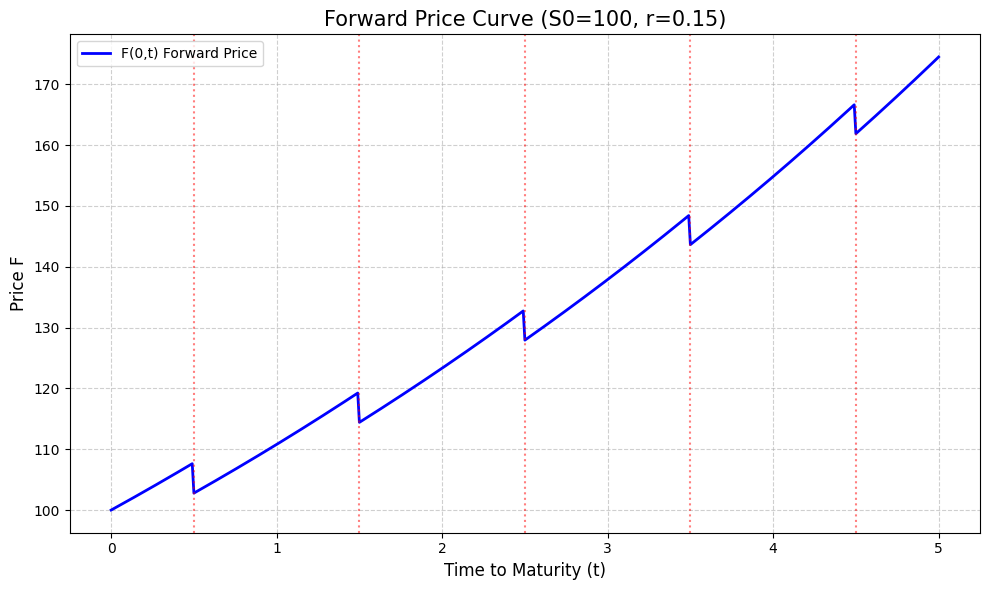

In [323]:
plt.figure(figsize=(10, 6))

plt.plot(t, F, color='blue', linewidth=2, label='F(0,t) Forward Price')

for val in tau:
    plt.axvline(x=val, color='red', linestyle=':', alpha=0.5)

plt.title(f'Forward Price Curve (S0={S_0}, r={r})', fontsize=15)
plt.xlabel('Time to Maturity (t)', fontsize=12)
plt.ylabel('Price F', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

2. **(15 points)** Using the Monte-Carlo method, obtain the prices of vanilla options (in terms of Black implied volatilities) with maturity $T=5$ years. Use the strikes $K$ ranging from $40$ to $160$ with step $5$. Your answer should contain an implied volatilities curve plot.

We obtain approximation of PV_call by the Monte-Carlo method with N_num simulations, like discounted average value of payoff $(S_T^i - K)^{+}$ (the first fundamental theorem + approximation of the expectation).
And by this $PV_T^N$ we obtain implied volatility by the best '*lets be rational*' algorithm(using Black-formula with $F_{0, T}$(1.1) and $P_{0, T} = e ^ {rT}$ ).

In [324]:
sigma = 0.25
N_sim = 500_000

In [325]:
time_grid = np.concatenate([[0.0], tau, [T]])
print(time_grid)
intervals = np.diff(time_grid)
print(intervals)
d_with_bound = np.append(d, 0)

S = np.full(N_sim, S_0)

for k, dt in enumerate(intervals):
    Z = np.random.standard_normal(N_sim)
    S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    t_end = time_grid[k + 1]
    S = S - d_with_bound[k]

S_T = S


[0.  0.5 1.5 2.5 3.5 4.5 5. ]
[0.5 1.  1.  1.  1.  0.5]


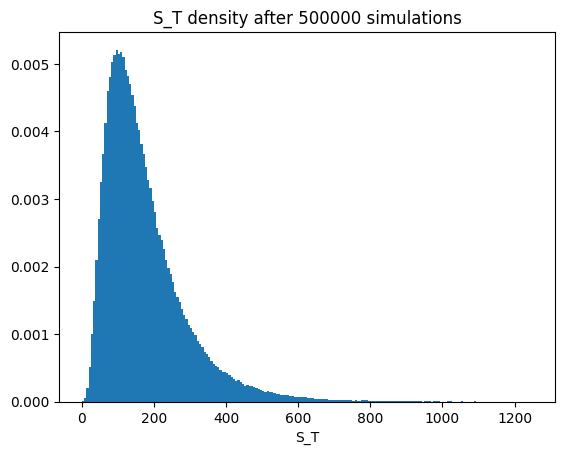

In [326]:
plt.hist(S_T, bins = 200, range=(0, 1250), density=True)
plt.title("S_T density after " + str(N_sim) + " simulations")
plt.xlabel("S_T")
plt.show()

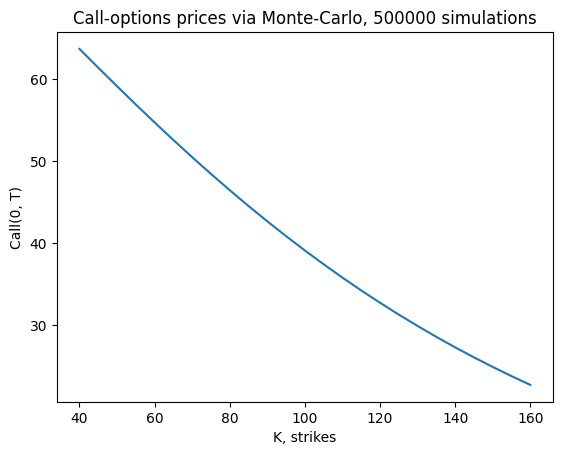

In [327]:
strikes = np.arange(40, 165, 5, dtype=float)
df = np.exp(-r * T)

call_prices = np.array([df * np.mean(np.maximum(S_T - K, 0.0)) for K in strikes])

plt.plot(strikes, call_prices)
plt.title("Call-options prices via Monte-Carlo, " + str(N_sim) + " simulations")
plt.xlabel("K, strikes")
plt.ylabel("Call(0, T)")
plt.show()

In [328]:
F0_T = F[-1]
impl_vols = py_vollib_vectorized.vectorized_implied_volatility_black(call_prices, F0_T, strikes, r, T, flag='c', return_as='numpy')
print(impl_vols)


[0.3108697  0.30362625 0.29858896 0.29497299 0.29217953 0.28991196
 0.28805279 0.28654875 0.28531142 0.28422939 0.28329771 0.28247471
 0.28174188 0.28107459 0.28045219 0.27988814 0.27937074 0.27887653
 0.27841124 0.27796638 0.27754968 0.27715625 0.27678301 0.27642247
 0.27607942]


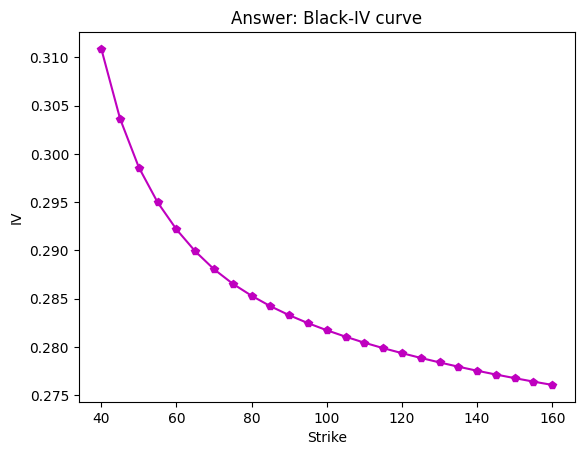

In [329]:
plt.plot(strikes, impl_vols, 'm-p')
plt.title("Answer: Black-IV curve")
plt.xlabel("Strike")
plt.ylabel("IV")
plt.show()

3. **(10 points)** Show that your Monte-Carlo algorithm converges in terms of decreasing empirical (relative) error when the number of simulations increases. Your answer should contain a plot of error as a function of number of simulations.


A formulae for relative error:
$$err_r^n = \frac{|PV_N - PV_n|}{PV_N},$$
where $PV_n = ( \sum_{i = 1} ^ n (S_T^i - K)^{+} / n) \cdot P(0, T)$ - result of the Monte-Carlo approach with n simulations. Note, that we can reduce $P(0, T)$ both in denominator and numerator and must make independent samples, not subsets.

In [330]:
def Monte_Carlo_simulations(T: float, r: float, sigma: float,
                           tau: np.ndarray, d: np.ndarray, N_sim: int):
  time_grid = np.concatenate([[0.0], tau, [T]])
  intervals = np.diff(time_grid)
  d_with_bound = np.append(d, 0)

  S = np.full(N_sim, S_0)

  for k, dt in enumerate(intervals):
      Z = np.random.standard_normal(N_sim)
      S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
      t_end = time_grid[k + 1]
      S = S - d_with_bound[k]

  S_T = S
  return S_T

In [331]:
def call_payoffs(S_T: np.ndarray, strikes: np.ndarray):
  return np.array([np.mean(np.maximum(S_T - K, 0.0)) for K in strikes])

In [332]:
def Monte_Carlo_expect_call_payoff(T: float, strikes: np.ndarray, r: float, sigma: float,
                           tau: np.ndarray, d: np.ndarray, N_sim: int):
  ST_MC = Monte_Carlo_simulations(T, r, sigma, tau, d, N_sim)
  return call_payoffs(ST_MC, strikes)

Lets draw plot for K = 90 = strikes[10] and the whole surface $err_r(n, K)$:

In [333]:
N = 10_000_000
ns = np.logspace(2, 7, 15).astype(int)
errors_n_K = np.zeros((len(ns), len(strikes)))
N_exp_payoff = Monte_Carlo_expect_call_payoff(T, strikes, r, sigma, tau, d, ns[-1])
for i in range(len(ns) - 1):
  n = ns[i]
  cur_exp_payoff = Monte_Carlo_expect_call_payoff(T, strikes, r, sigma, tau, d, n)
  errors_n_K[i] = np.absolute(cur_exp_payoff - N_exp_payoff) / N_exp_payoff

Theoretical order of Monte-Carlo convergence is $\frac{1}{\sqrt{n}}$.

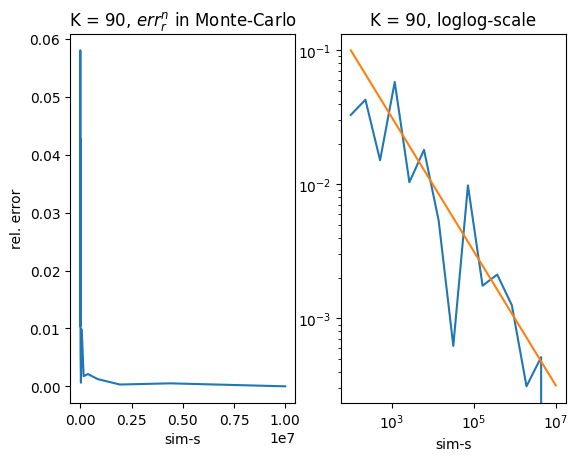

In [334]:
plt.figure()
plt.subplot(121)
plt.plot(ns, errors_n_K[:, 10])
plt.title("K = 90, $err_r^n$ in Monte-Carlo")
plt.xlabel("sim-s")
plt.ylabel("rel. error")

plt.subplot(122)
plt.title("K = 90, loglog-scale")
plt.xlabel("sim-s")
plt.loglog(ns, errors_n_K[:, 10])
plt.loglog(ns, 1 / np.sqrt(ns))

plt.show()

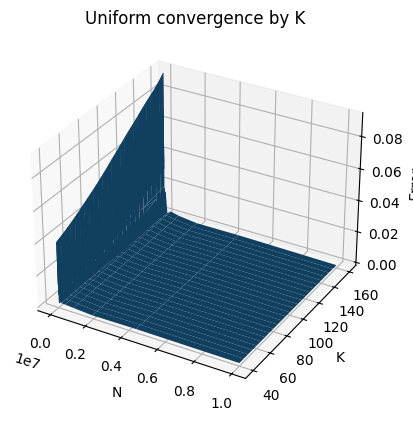

In [335]:
Ns, K = np.meshgrid(ns, strikes, indexing='ij')

plt.figure()
#plt.title("Uniform convergence by K")
ax = plt.axes(projection='3d')
ax.plot_surface(Ns, K, errors_n_K)
ax.set_xlabel('N')
ax.set_ylabel('K')
ax.set_zlabel('Error')
ax.set_title('Uniform convergence by K')

plt.show()

4. **(10 points)** As a sanity check of your simulations algorithm, show that the empirically averaged stock sprice $S_T$ converges to a forward price $F_{0, T}$ when number of monte carlo simulations increases.

In [336]:
F0_T = F[-1]

ns = np.logspace(2, 7, 15).astype(int)
ST_L1_errors = np.zeros(len(ns))
print(ns)

for i in range(len(ns)):
  ST_cur = Monte_Carlo_simulations(T, r, sigma, tau, d, ns[i])
  ST_L1_errors[i] = np.mean(ST_cur) - F0_T

print(ST_L1_errors)

[     100      227      517     1178     2682     6105    13894    31622
    71968   163789   372759   848342  1930697  4393970 10000000]
[-0.59945224  0.43395385 -3.92302389 -0.75024969 -3.49339467 -1.58664455
  0.75604374 -0.41719344  0.30222509  0.73194888  0.38216628 -0.06273574
  0.0834737  -0.05950031  0.01358121]


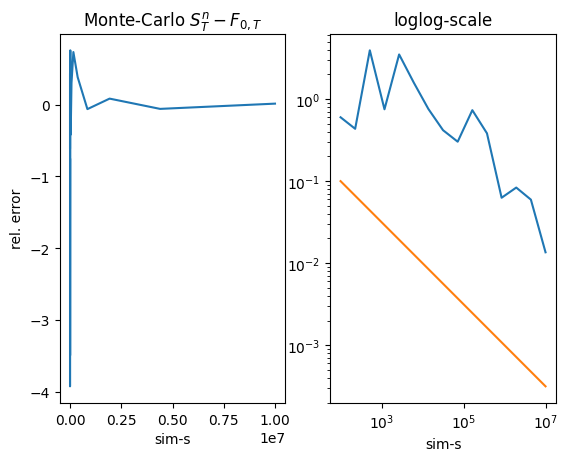

In [337]:
plt.figure()
plt.subplot(121)
plt.plot(ns, ST_L1_errors)
plt.title("Monte-Carlo $S_T^n - F_{0, T}$")
plt.xlabel("sim-s")
plt.ylabel("rel. error")

plt.subplot(122)
plt.title("loglog-scale")
plt.xlabel("sim-s")
plt.loglog(ns, np.absolute(ST_L1_errors))
plt.loglog(ns, 1 / np.sqrt(ns))

plt.show()

### 2. Cash Dividend Model approximations (60 points)

Using option prices obtained in the problem above, compute implied volatilities corresponding to each of the following affine approximations of the Cash Dividend Model.  Each of your answers should contain an implied volatilities curve plot.

For each model, make your conclusion about the quality of the approximation. What happens with the implied volatility when the valuation date passes the ex-dividend date? When the option's expiry date passes the ex-div date?

1. **(15 points)** **Forward (Black) model**

In [338]:
def forw_IV(call_prices: np.ndarray, strikes: np.ndarray, r: float, T: float,
            d: np.ndarray, tau: np.ndarray):
  PV_future_divs_init = np.sum(d * np.exp((-r) * tau))
  g_T = (S_0 - PV_future_divs_init) * np.exp(r * T)
  h_T = 0
  return py_vollib_vectorized.vectorized_implied_volatility_black(call_prices, g_T, strikes - h_T, r, T, flag='c', return_as='numpy')

2. **(20 points)** **Spot model**

In [339]:
def spot_IV(call_prices: np.ndarray, strikes: np.ndarray, r: float, T: float,
            d: np.ndarray, tau: np.ndarray):
  PV_future_divs_init = np.sum(d * np.exp((-r) * tau))
  g_T = S_0 * np.exp(r * T)
  h_T = (-np.exp(r * T)) * PV_future_divs_init
  return py_vollib_vectorized.vectorized_implied_volatility_black(call_prices, g_T, strikes - h_T, r, T, flag='c', return_as='numpy')

3. **(25 points)** **Bos-Vandermark model**

In [340]:
def bos_IV(call_prices: np.ndarray, strikes: np.ndarray, r: float, T: float,
            d: np.ndarray, tau: np.ndarray):
  PV_future_divs_init = np.sum(d * np.exp((-r) * tau))
  PV_near_divs_init = np.sum(((T - tau) / T) * d * np.exp((-r) * tau))
  g_T = (S_0 - PV_near_divs_init) * np.exp(r * T)
  h_T = (-np.exp(r * T)) * (PV_future_divs_init - PV_near_divs_init)
  return py_vollib_vectorized.vectorized_implied_volatility_black(call_prices, g_T, strikes - h_T, r, T, flag='c', return_as='numpy')

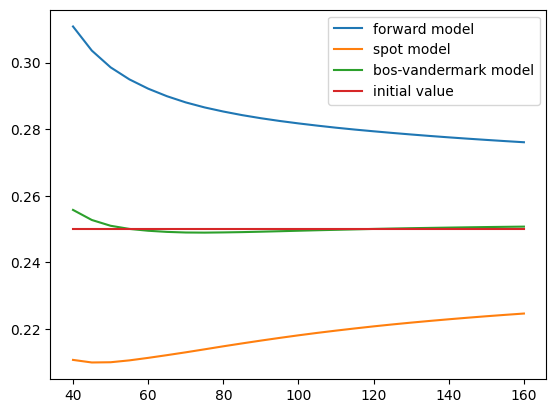

In [341]:
plt.plot(strikes, forw_IV(call_prices, strikes, r, T, d, tau), label='forward model')
plt.plot(strikes, spot_IV(call_prices, strikes, r, T, d, tau), label='spot model')
plt.plot(strikes, bos_IV(call_prices, strikes, r, T, d, tau), label='bos-vandermark model')
plt.plot(strikes, sigma * np.ones(len(strikes)), label='initial value')

plt.legend()
plt.show()

We see maximum accuracy in the Bos-Vandermark model.  The forward model overestimates volatility, while the spot model underestimates it by 2-5%.

At the same time, accuracy is poor on small strikes and it improves as the strike increases.

When the valuation date exceeds the dividend payment date, we switch to the usual Black-Scholes situation - the stock price is a regular Brownian motion with constant volatility and discounting. Then all the models turn into the classic Black model and the answer should be with good accuracy, like the 'lets be rational' algorithm.

When the expiration date of the option exceeds the ex-div date, on the contrary, the maximum number of dividend dates will pass and there will be a greater deviation from the true value of volatility in all models.